
# Machine learning - Part 3: Classification 

By the end of this module, students should be able to:

- distinguish between classification and regression
- explain how Logistic Regression, KNN, and Decision Trees work at a conceptual level
- interpret probabilities and classification thresholds
- evaluate models using accuracy, precision, recall, F1, and ROC AUC
- read and interpret a confusion matrix
- understand trade-offs between precision and recall
- train and apply basic classification models in scikit-learn
- interpret model outputs (coefficients, feature importance)
- compare models and choose one based on problem context

In [1]:

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

from sklearn.preprocessing import StandardScaler

%matplotlib inline



# Part 1: What is classification?

A **classification problem** is a machine learning problem where the target is a **category**.

Examples:
- spam or not spam
- fraud or not fraud
- churn or not churn
- approved or denied
- disease or no disease

In this notebook, we will predict:

- **churn = 1** → customer leaves
- **churn = 0** → customer stays

---

## Classification vs regression

### Regression
Predicts a number  
Examples:
- house price
- salary
- sales amount

### Classification
Predicts a label or class  
Examples:
- yes / no
- 0 / 1
- cat / dog / bird

Even when classes are coded as `0` and `1`, the problem is still classification.



## Dataset for this session

We will use a practical customer-style churn dataset.

**File used:** `customer_churn_classification.csv`

The target column is:

- `churn`

Possible values:
- `0` = customer stays
- `1` = customer churns


In [2]:

# Load the dataset
df = pd.read_csv("customer_churn_classification.csv")

# Show the first 5 rows
df.head()


,age,income_k,monthly_spend,website_visits,support_tickets,tenure_months,last_login_days,used_discount,premium_plan,auto_pay,num_products,churn
0,22,82.3,124.2,13,1,51,13.2,0,0,1,5,0
1,59,116.6,85.4,6,2,31,17.4,1,1,0,3,0
2,52,25.0,123.9,4,2,25,16.5,0,1,0,4,0
3,41,43.1,84.3,9,1,33,8.8,0,0,1,5,0
4,40,59.2,70.5,8,0,22,18.5,0,1,1,1,0


In [ ]:

# Basic shape and data types
print("Rows and columns:", df.shape)
print()
print(df.dtypes)


In [3]:

# Summary statistics
df.describe()


,age,income_k,monthly_spend,website_visits,support_tickets,tenure_months,last_login_days,used_discount,premium_plan,auto_pay,num_products,churn
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,44.251333,83.800467,121.642267,9.877333,1.797333,36.700667,13.163200,0.456000,0.350667,0.524667,3.082000,0.155333
std,15.315631,27.595942,44.945907,3.156728,1.324675,20.427855,9.029982,0.498226,0.477338,0.499558,1.428508,0.362343
min,18.000000,25.000000,10.000000,0.000000,0.000000,1.000000,0.600000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,31.000000,65.100000,90.500000,8.000000,1.000000,19.000000,6.600000,0.000000,0.000000,0.000000,2.000000,0.000000
50%,44.000000,85.100000,121.500000,10.000000,2.000000,37.000000,11.000000,0.000000,0.000000,1.000000,3.000000,0.000000
75%,58.000000,101.900000,152.700000,12.000000,3.000000,54.000000,17.400000,1.000000,1.000000,1.000000,4.000000,0.000000
max,70.000000,174.000000,259.000000,21.000000,8.000000,72.000000,60.000000,1.000000,1.000000,1.000000,5.000000,1.000000


In [ ]:

# Check class balance
df["churn"].value_counts()


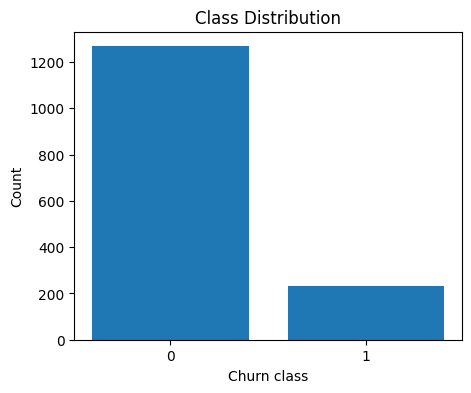

In [4]:

# Visualize class balance
class_counts = df["churn"].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel("Churn class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()



## Why class balance matters

If one class is much more common than the other, then **accuracy can be misleading**.

Example:
- Suppose 95% of customers stay
- A silly model that always predicts "stay" gets 95% accuracy
- But it completely fails to detect churn

This is why we need more than one metric.



# Part 2: Features and target

In machine learning:

- **X** = features (input variables)
- **y** = target (what we want to predict)


In [5]:

# Define features and target
X = df.drop(columns="churn")
y = df["churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1500, 11)
y shape: (1500,)



## Train/test split

We train on one part of the data and test on unseen data.

This helps us estimate how the model might perform in the real world.


In [6]:

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (1200, 11)
Test set: (300, 11)



# Part 3: Logistic Regression theory

Despite its name, **Logistic Regression is a classification model**, not a regression model.

It is mainly used for **binary classification**.

---

## Core idea

Logistic Regression first builds a linear score:

$
z = b_0 + b_1x_1 + b_2x_2 + \dots + b_px_p
$

But instead of using that score directly, it passes the score into the **sigmoid function**:

$
p = \frac{1}{1 + e^{-z}}
$

This converts any real number into a value between 0 and 1.

That value can be interpreted as a **probability**.

---

## Why do we need the sigmoid?

A plain linear model can produce any number:
- -5
- 12
- 300

But probabilities must stay between:
- 0 and 1

The sigmoid fixes that.


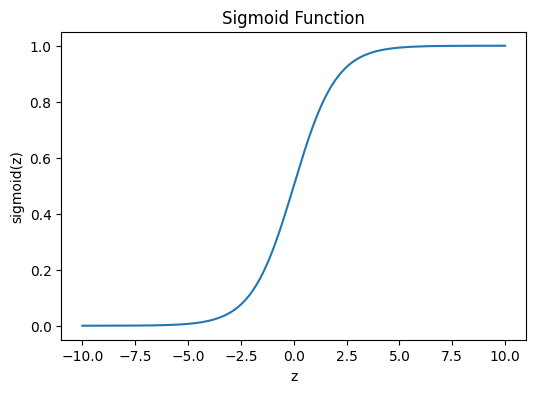

In [7]:

# Demo: the sigmoid function
z = np.linspace(-10, 10, 300)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(6, 4))
plt.plot(z, sigmoid)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.show()



## How to read the sigmoid curve

- very negative \(z\) → probability close to 0
- \(z = 0\) → probability = 0.5
- very positive \(z\) → probability close to 1

So Logistic Regression is really learning a weighted score, then converting it into a probability.



## From probability to final class

After predicting a probability, the model must decide the class.

A common default rule is:

- if probability >= 0.5, predict class 1
- otherwise, predict class 0

This is called a **threshold**.

Important:
- the model predicts probabilities
- the threshold converts probabilities into class labels



## What does Logistic Regression optimize?

Linear regression minimizes squared error.

Logistic Regression usually minimizes **log loss** (also called cross-entropy loss).

For binary classification, the idea is:

- reward confident correct predictions
- strongly punish confident wrong predictions

We will not derive the full optimization in detail here, but conceptually it tries to find coefficients that make the predicted probabilities align well with the true classes.



# Part 4: Why scaling matters for some classification models

Models like:
- Logistic Regression
- KNN

usually work better when features are on a similar scale.

For example:
- `income_k` might be around 100
- `support_tickets` might be around 2

Without scaling, the larger-scale feature can dominate the model.

We will standardize features using:

$
x_{scaled} = \frac{x - \text{mean}}{\text{std}}
$


In [8]:

# Scale features using training data only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)


Scaled training shape: (1200, 11)
Scaled test shape: (300, 11)



# Part 5: Train a Logistic Regression model


In [9]:

# Create and train Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained.")


Logistic Regression model trained.


In [10]:

# Predict class labels
log_pred = log_model.predict(X_test_scaled)

# Predict class probabilities
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# Show a few predictions
comparison_df = pd.DataFrame({
    "actual": y_test.iloc[:10].values,
    "predicted_class": log_pred[:10],
    "predicted_probability_of_churn": np.round(log_prob[:10], 3)
})

comparison_df


,actual,predicted_class,predicted_probability_of_churn
0,0,0,0.335
1,0,0,0.055
2,1,0,0.119
3,0,0,0.073
4,0,0,0.099
5,0,0,0.098
6,0,0,0.074
7,0,0,0.146
8,0,0,0.170
9,0,0,0.125



## What is `predict_proba()`?

For binary classification, `predict_proba()` returns two probabilities:

- probability of class 0
- probability of class 1

If we use:

```python
model.predict_proba(X)[:, 1]
```

we get the probability of class 1.


In [11]:

# Show both probabilities for the first 5 observations
log_model.predict_proba(X_test_scaled[:5])


array([[0.66520049, 0.33479951],
       [0.94535806, 0.05464194],
       [0.88122152, 0.11877848],
       [0.92733612, 0.07266388],
       [0.90145748, 0.09854252]])


# Part 6: Classification metrics

For classification, one metric is rarely enough.

---

## 1. Accuracy

$
\text{Accuracy} = \frac{\text{correct predictions}}{\text{all predictions}}
$

Good when:
- classes are balanced
- mistakes have similar cost

But accuracy alone can be misleading.

---

## 2. Confusion Matrix

For binary classification:

- **True Positive (TP)**: predicted 1, actual 1
- **True Negative (TN)**: predicted 0, actual 0
- **False Positive (FP)**: predicted 1, actual 0
- **False Negative (FN)**: predicted 0, actual 1

This matrix is the foundation for several metrics.


In [12]:

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, log_pred), 4))


Accuracy: 0.8467


In [13]:

# Confusion matrix
cm = confusion_matrix(y_test, log_pred)
cm


array([[251,   2],
       [ 44,   3]])

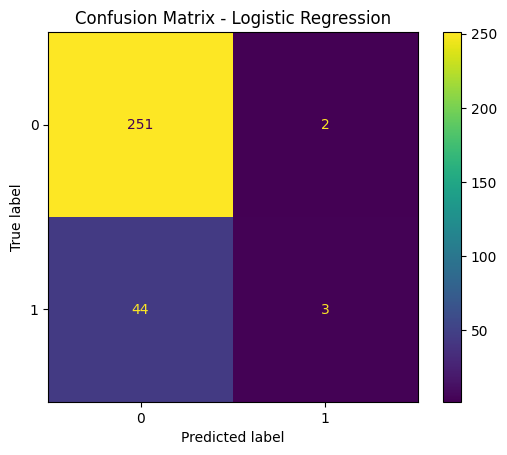

In [14]:

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()



## 3. Precision

$
\text{Precision} = \frac{TP}{TP + FP}
$

Interpretation:
- of the cases predicted as positive, how many were truly positive?

Use precision when **false positives are costly**.

---

## 4. Recall

$
\text{Recall} = \frac{TP}{TP + FN}
$

Interpretation:
- of the truly positive cases, how many did we find?

Use recall when **false negatives are costly**.

---

## 5. F1 Score

\[
F1 = 2 \cdot \frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}
\]

Interpretation:
- balance between precision and recall

---

## 6. ROC AUC

AUC measures ranking quality across many thresholds.

Higher AUC means the model is better at separating the positive class from the negative class.


In [15]:

# Compute main classification metrics
acc = accuracy_score(y_test, log_pred)
prec = precision_score(y_test, log_pred)
rec = recall_score(y_test, log_pred)
f1 = f1_score(y_test, log_pred)
auc = roc_auc_score(y_test, log_prob)

print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1 Score :", round(f1, 4))
print("ROC AUC  :", round(auc, 4))


Accuracy : 0.8467
Precision: 0.6
Recall   : 0.0638
F1 Score : 0.1154
ROC AUC  : 0.6814


In [16]:

# Full classification report
print(classification_report(y_test, log_pred))


              precision    recall  f1-score   support

           0       0.85      0.99      0.92       253
           1       0.60      0.06      0.12        47

    accuracy                           0.85       300
   macro avg       0.73      0.53      0.52       300
weighted avg       0.81      0.85      0.79       300




## Why probability threshold matters

The default threshold is 0.5, but that is not always the best choice.

If we lower the threshold:
- the model predicts more positives
- recall often goes up
- precision may go down

If we raise the threshold:
- the model becomes more conservative
- precision may go up
- recall may go down


In [17]:

# Demo: how threshold changes predictions
thresholds = [0.3, 0.5, 0.7]
rows = []

for t in thresholds:
    pred_t = (log_prob >= t).astype(int)

    rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, pred_t),
        "precision": precision_score(y_test, pred_t),
        "recall": recall_score(y_test, pred_t),
        "f1": f1_score(y_test, pred_t)
    })

pd.DataFrame(rows)


c:\Users\hlu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,threshold,accuracy,precision,recall,f1
0,0.3,0.816667,0.382353,0.276596,0.320988
1,0.5,0.846667,0.600000,0.063830,0.115385
2,0.7,0.843333,0.000000,0.000000,0.000000



This threshold table is very important for beginners.

It shows that classification is not just about a model.  
It is also about a **decision rule**.



# Part 7: K-Nearest Neighbors (KNN) theory

KNN is very different from Logistic Regression.

It does not fit a global equation like:

\[
b_0 + b_1x_1 + b_2x_2 + \dots
\]

Instead, KNN predicts by looking at the **nearest training points**.

---

## Core idea

To classify a new point:

1. measure distance to training points
2. find the \(k\) nearest neighbors
3. let them vote
4. predict the majority class

---

## Role of \(k\)

- small \(k\): more flexible, more sensitive to noise
- large \(k\): smoother, more stable, but may miss local patterns

---

## Why scaling matters a lot for KNN

KNN uses distance.

If one feature has a much bigger scale than others, it can dominate the distance calculation.



## Tiny intuition demo for KNN

Suppose a new customer is close to several churned customers.  
KNN may predict churn because its neighbors mostly churned.

KNN is often easy to explain, but it can become slower on large datasets.


In [18]:

# Train a simple KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Predict labels and probabilities
knn_pred = knn_model.predict(X_test_scaled)
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

print("KNN model trained.")


KNN model trained.


In [19]:

# Evaluate KNN
print("Accuracy :", round(accuracy_score(y_test, knn_pred), 4))
print("Precision:", round(precision_score(y_test, knn_pred), 4))
print("Recall   :", round(recall_score(y_test, knn_pred), 4))
print("F1 Score :", round(f1_score(y_test, knn_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, knn_prob), 4))


Accuracy : 0.8267
Precision: 0.3684
Recall   : 0.1489
F1 Score : 0.2121
ROC AUC  : 0.5838


In [20]:

# Demo: effect of different k values
k_values = [1, 3, 5, 9, 15]
knn_rows = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    prob = model.predict_proba(X_test_scaled)[:, 1]

    knn_rows.append({
        "k": k,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, prob)
    })

pd.DataFrame(knn_rows)


,k,accuracy,precision,recall,f1,roc_auc
0,1,0.796667,0.340909,0.319149,0.329670,0.602262
1,3,0.813333,0.333333,0.191489,0.243243,0.589311
2,5,0.826667,0.368421,0.148936,0.212121,0.583761
3,9,0.833333,0.333333,0.063830,0.107143,0.558910
4,15,0.850000,0.666667,0.085106,0.150943,0.602472



Students should notice:
- KNN behavior depends on \(k\)
- there is usually a trade-off between flexibility and stability



# Part 8: Decision Tree theory

A Decision Tree makes predictions by asking a sequence of questions.

Example:
- Is tenure less than 12 months?
- Is last login more than 20 days ago?
- Are support tickets high?

Based on these splits, the tree moves to a final prediction.

---

## Why trees are popular

They are:
- easy to visualize
- easy to explain
- able to capture non-linear patterns
- able to handle interactions between features

---

## What does a Decision Tree try to optimize?

At each split, the tree wants to make groups that are more "pure."

A common impurity measure is **Gini impurity**:

\[
Gini = 1 - \sum p_k^2
\]

If a node contains mostly one class, impurity is low.

The tree searches for splits that reduce impurity as much as possible.


In [21]:

# Train a small Decision Tree
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

# Predict labels and probabilities
tree_pred = tree_model.predict(X_test)
tree_prob = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree model trained.")


Decision Tree model trained.


In [22]:

# Evaluate Decision Tree
print("Accuracy :", round(accuracy_score(y_test, tree_pred), 4))
print("Precision:", round(precision_score(y_test, tree_pred), 4))
print("Recall   :", round(recall_score(y_test, tree_pred), 4))
print("F1 Score :", round(f1_score(y_test, tree_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, tree_prob), 4))


Accuracy : 0.83
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.6653


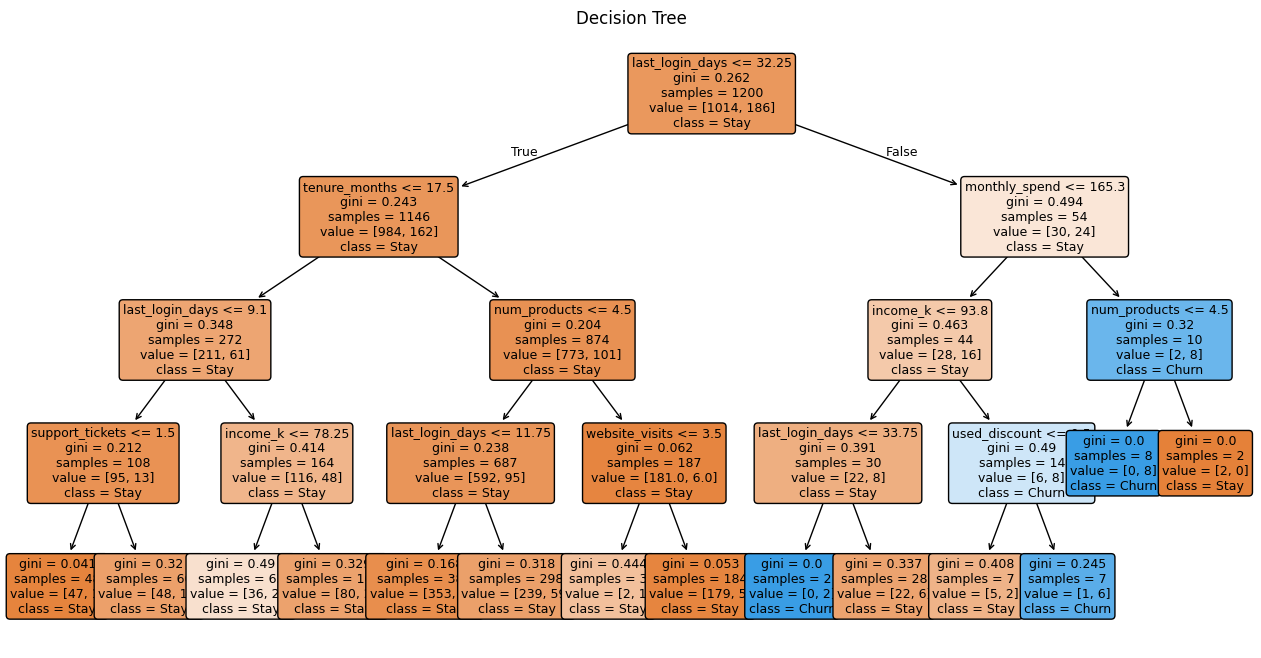

In [23]:

# Visualize the tree
plt.figure(figsize=(16, 8))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Stay", "Churn"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree")
plt.show()



## How to read the tree

Each box shows:
- a splitting rule
- impurity
- sample count
- predicted class

Students should read it from top to bottom like a sequence of business rules.


In [24]:

# Feature importance from the tree
tree_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": tree_model.feature_importances_
}).sort_values("importance", ascending=False)

tree_importance


,feature,importance
6,last_login_days,0.440652
10,num_products,0.148006
1,income_k,0.126101
5,tenure_months,0.111367
2,monthly_spend,0.070489
7,used_discount,0.051923
4,support_tickets,0.038891
3,website_visits,0.012571
0,age,0.000000
8,premium_plan,0.000000



# Part 9: Compare the three models


In [25]:

# Put model comparison into one table
results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, log_pred),
        "precision": precision_score(y_test, log_pred),
        "recall": recall_score(y_test, log_pred),
        "f1": f1_score(y_test, log_pred),
        "roc_auc": roc_auc_score(y_test, log_prob)
    },
    {
        "model": "KNN",
        "accuracy": accuracy_score(y_test, knn_pred),
        "precision": precision_score(y_test, knn_pred),
        "recall": recall_score(y_test, knn_pred),
        "f1": f1_score(y_test, knn_pred),
        "roc_auc": roc_auc_score(y_test, knn_prob)
    },
    {
        "model": "Decision Tree",
        "accuracy": accuracy_score(y_test, tree_pred),
        "precision": precision_score(y_test, tree_pred),
        "recall": recall_score(y_test, tree_pred),
        "f1": f1_score(y_test, tree_pred),
        "roc_auc": roc_auc_score(y_test, tree_prob)
    }
])

results.sort_values("f1", ascending=False)


,model,accuracy,precision,recall,f1,roc_auc
1,KNN,0.826667,0.368421,0.148936,0.212121,0.583761
0,Logistic Regression,0.846667,0.600000,0.063830,0.115385,0.681356
2,Decision Tree,0.830000,0.000000,0.000000,0.000000,0.665251



## How should beginners compare models?

Do not look at only one metric.

Think about:

- Is class balance reasonable?
- Are false positives costly?
- Are false negatives costly?
- Do we care more about precision or recall?
- Do we want a model that is easy to explain?



# Part 10: ROC curve

The ROC curve shows how the model behaves across many thresholds.

It plots:
- **False Positive Rate** on the x-axis
- **True Positive Rate (Recall)** on the y-axis

The **AUC** summarizes the curve in one number.


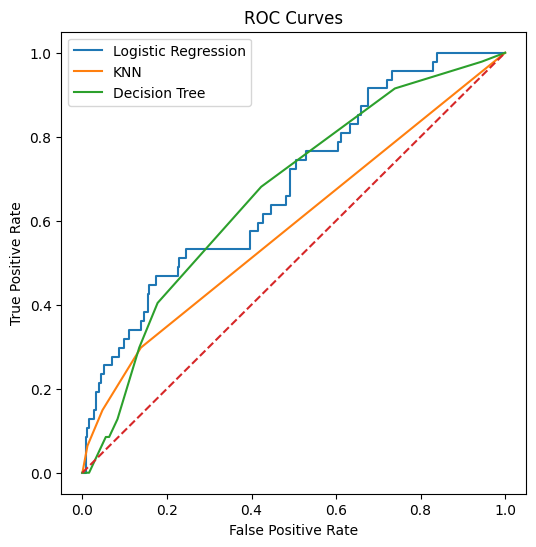

In [26]:

# Plot ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_knn, tpr_knn, label="KNN")
plt.plot(fpr_tree, tpr_tree, label="Decision Tree")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()



## Why ROC AUC is useful

AUC is useful because it measures how well the model ranks positives above negatives across many thresholds.

Still, it does **not** replace the confusion matrix or threshold-based metrics.  
It is one more useful view, not the only view.



# Part 11: Interpreting Logistic Regression coefficients

For Logistic Regression, coefficients affect the **log-odds** of the positive class.

That sounds technical, so for beginners we can use this simpler interpretation:

- positive coefficient → feature pushes probability upward
- negative coefficient → feature pushes probability downward

Because we scaled the features, the coefficient magnitudes are somewhat more comparable.


In [27]:

# Logistic Regression coefficients
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_model.coef_[0]
}).sort_values("coefficient", ascending=False)

coef_df


,feature,coefficient
6,last_login_days,0.440521
4,support_tickets,0.259191
7,used_discount,0.228699
2,monthly_spend,0.152169
0,age,0.079233
1,income_k,-0.080298
3,website_visits,-0.105576
8,premium_plan,-0.224191
5,tenure_months,-0.328781
10,num_products,-0.336008


In [28]:

# Show strongest positive and negative effects
top_positive = coef_df.head(5)
top_negative = coef_df.tail(5).sort_values("coefficient")

print("Features pushing churn probability up")
display(top_positive)

print("\nFeatures pushing churn probability down")
display(top_negative)


Features pushing churn probability up


,feature,coefficient
6,last_login_days,0.440521
4,support_tickets,0.259191
7,used_discount,0.228699
2,monthly_spend,0.152169
0,age,0.079233



Features pushing churn probability down


,feature,coefficient
9,auto_pay,-0.390867
10,num_products,-0.336008
5,tenure_months,-0.328781
8,premium_plan,-0.224191
3,website_visits,-0.105576



## Discussion

Which results make business sense?

For example:
- more support tickets might increase churn risk
- longer tenure might reduce churn risk
- auto-pay might reduce churn risk

This is the kind of interpretation students should practice.



# Part 12: Strengths and weaknesses of the models

## Logistic Regression
**Strengths**
- simple
- fast
- probability output
- interpretable

**Weaknesses**
- mainly linear decision boundary
- may miss complex relationships

## KNN
**Strengths**
- intuitive
- no explicit training formula to learn
- flexible local behavior

**Weaknesses**
- sensitive to scale
- can be slow on larger datasets
- choice of \(k\) matters

## Decision Tree
**Strengths**
- interpretable rules
- captures non-linearity
- easy to visualize

**Weaknesses**
- can overfit
- can be unstable
- small data changes may change the tree



# Part 13: Hands-on exercises

## Exercise 1
Explain in words:
- classification
- probability
- threshold

## Exercise 2
Why is Logistic Regression still a classification model even though its name contains "regression"?

## Exercise 3
Train Logistic Regression and change the threshold to:
- 0.4
- 0.6

How do precision and recall change?

## Exercise 4
Train KNN with:
- `k=3`
- `k=11`

How do the metrics change?

## Exercise 5
Train a deeper Decision Tree with:
- `max_depth=6`

Does performance improve? Does interpretability get worse?

## Exercise 6
Which model would you choose if:
- false negatives matter most?
- interpretability matters most?
- you want a very simple baseline?

## Exercise 7
In plain English, explain:
- accuracy
- precision
- recall
- F1
- ROC AUC


In [29]:

# Starter code for Exercise 3: threshold comparison
for t in [0.4, 0.6]:
    pred_t = (log_prob >= t).astype(int)
    print(f"Threshold = {t}")
    print("Precision:", round(precision_score(y_test, pred_t), 4))
    print("Recall   :", round(recall_score(y_test, pred_t), 4))
    print("F1 Score :", round(f1_score(y_test, pred_t), 4))
    print()


Threshold = 0.4
Precision: 0.5
Recall   : 0.1277
F1 Score : 0.2034

Threshold = 0.6
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0



In [30]:

# Starter code for Exercise 4: try different k values
for k in [3, 11]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    print(f"k = {k}")
    print("Accuracy :", round(accuracy_score(y_test, pred), 4))
    print("Precision:", round(precision_score(y_test, pred), 4))
    print("Recall   :", round(recall_score(y_test, pred), 4))
    print("F1 Score :", round(f1_score(y_test, pred), 4))
    print()


k = 3
Accuracy : 0.8133
Precision: 0.3333
Recall   : 0.1915
F1 Score : 0.2432

k = 11
Accuracy : 0.8467
Precision: 0.6
Recall   : 0.0638
F1 Score : 0.1154




# Part 14: Key takeaways

- Classification predicts a **category**
- Logistic Regression predicts a **probability**, then uses a threshold
- KNN predicts using the **nearest neighbors**
- Decision Trees predict using **if-then style rules**
- Accuracy is useful, but often not enough
- Precision, recall, and F1 are essential for understanding trade-offs
- ROC AUC helps evaluate ranking quality across thresholds
- Model choice depends on:
  - data
  - business context
  - explainability needs
  - error costs
